**Data setup and Loading**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Load data
df = pd.read_csv('/content/2020-Jan.csv')
print(df.shape) #how many rows and columns
print(df.head()) #first 5 rows
print(df.info()) #data types
print(df.describe()) #describes the data
print(df.isnull()) #missing values
print(df.isnull().sum()) #missing values per column
print(df.isnull().sum().sum()) #total missing values
print(df['event_type'].value_counts()) #view/cart/purchase counts

(4264752, 9)
                event_time event_type  product_id          category_id  \
0  2020-01-01 00:00:00 UTC       view     5809910  1602943681873052386   
1  2020-01-01 00:00:09 UTC       view     5812943  1487580012121948301   
2  2020-01-01 00:00:19 UTC       view     5798924  1783999068867920626   
3  2020-01-01 00:00:24 UTC       view     5793052  1487580005754995573   
4  2020-01-01 00:00:25 UTC       view     5899926  2115334439910245200   

  category_code     brand  price    user_id  \
0           NaN   grattol   5.24  595414620   
1           NaN  kinetics   3.97  595414640   
2           NaN    zinger   3.97  595412617   
3           NaN       NaN   4.92  420652863   
4           NaN       NaN   3.92  484071203   

                           user_session  
0  4adb70bb-edbd-4981-b60f-a05bfd32683a  
1  c8c5205d-be43-4f1d-aa56-4828b8151c8a  
2  46a5010f-bd69-4fbe-a00d-bb17aa7b46f3  
3  546f6af3-a517-4752-a98b-80c4c5860711  
4  cff70ddf-529e-4b0c-a4fc-f43a749c0acb  
<class 

By the above data, we can see that view to purchase count has dropped badly and the funnel is leaking.

**Data Cleaning**
Cleaning up missing values, fix date and time formats for the analysis


In [12]:
#Fix datetime
df['event_time'] = pd.to_datetime(df['event_time'], format='mixed', errors='coerce', utc=True)
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()
df['month'] = df['event_time'].dt.month_name()
df['date'] = df['event_time'].dt.date

#Fill missing brand and category with "Unknown"
df['brand'] = df['brand'].fillna('Unknown')
df['category_code'] = df['category_code'].fillna('Unknown')

print("Cleaned data! Shape:", df.shape)
print(df.head())

Cleaned data! Shape: (1187666, 13)
                 event_time event_type  product_id          category_id  \
0 2020-01-01 00:00:00+00:00       view     5809910  1602943681873052386   
1 2020-01-01 00:00:09+00:00       view     5812943  1487580012121948301   
2 2020-01-01 00:00:19+00:00       view     5798924  1783999068867920626   
3 2020-01-01 00:00:24+00:00       view     5793052  1487580005754995573   
4 2020-01-01 00:00:25+00:00       view     5899926  2115334439910245200   

  category_code     brand  price    user_id  \
0       Unknown   grattol   5.24  595414620   
1       Unknown  kinetics   3.97  595414640   
2       Unknown    zinger   3.97  595412617   
3       Unknown   Unknown   4.92  420652863   
4       Unknown   Unknown   3.92  484071203   

                           user_session  hour day_of_week    month        date  
0  4adb70bb-edbd-4981-b60f-a05bfd32683a     0   Wednesday  January  2020-01-01  
1  c8c5205d-be43-4f1d-aa56-4828b8151c8a     0   Wednesday  January  2


Let's visualize the distribution of event types to identify potential leakage points in the sales funnel.

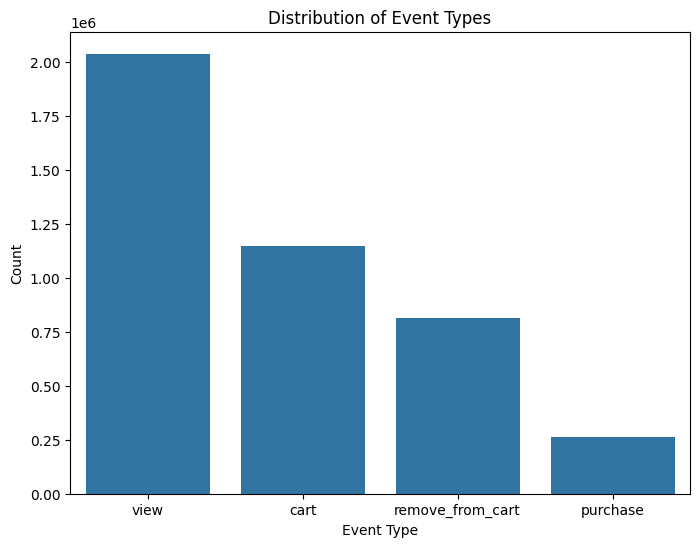

In [14]:

# Visualize the distribution of event types
plt.figure(figsize=(8, 6))
sns.countplot(x='event_type', data=df)
plt.title('Distribution of Event Types')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.show()


Conversion rates at each level

In [15]:
#Calculate unique users at each event type
view_users = df[df['event_type'] == 'view']['user_id'].nunique()
cart_users = df[df['event_type'] == 'cart']['user_id'].nunique()
purchase_users = df[df['event_type'] == 'purchase']['user_id'].nunique()

print(f"Views by Unique Users: {view_users}")
print(f"Carts by Unique Users: {cart_users}")
print(f"Purchases by Unique Users: {purchase_users}")

#Calculate Conversion rates
view_to_cart_conversion = (cart_users/view_users) * 100 if view_users > 0 else 0
cart_to_purchase_conversion = (purchase_users/cart_users) * 100 if cart_users > 0 else 0
view_to_purchase_conversion = (purchase_users/view_users) * 100 if view_users > 0 else 0

print(f"\nView to Cart Conversion Rate: {view_to_cart_conversion:.2f}%")
print(f"Cart to Purchase Conversion Rate: {cart_to_purchase_conversion:.2f}%")
print(f"View to purchase Conversion Rate: {view_to_purchase_conversion:.2f}%")

Views by Unique Users: 397775
Carts by Unique Users: 92653
Purchases by Unique Users: 28220

View to Cart Conversion Rate: 23.29%
Cart to Purchase Conversion Rate: 30.46%
View to purchase Conversion Rate: 7.09%


### Price Sensitivity Analysis

To understand price sensitivity, we need to analyze how different price points influence user behavior, particularly conversion rates. Let's start by examining the distribution of prices.

count    4.264752e+06
mean     8.713981e+00
std      1.963959e+01
min     -7.937000e+01
25%      2.350000e+00
50%      4.060000e+00
75%      7.140000e+00
max      3.277800e+02
Name: price, dtype: float64


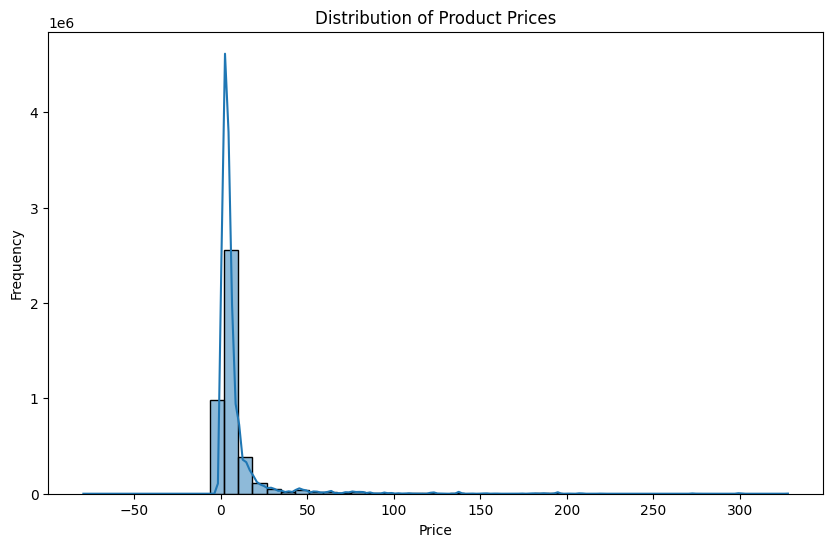

In [16]:
print(df['price'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Price Sensitivity analysis**
Lets analyze the conversion rate at which point users are mostly dropping to purchase the item. Does the price of the product influencing their decision?

In [25]:
df['price_category'] = pd.cut(df['price'],
bins = [0,10,25,50,100,999],
labels = ['<$10','$10-25','$25-50','$50-100','$100+'])
price_funnel = df.groupby(['price_category','event_type'], observed=False)['user_id'].count().unstack(fill_value = 0)
price_funnel['coversion_rate'] = (price_funnel['purchase']/price_funnel['view'])*100

In [30]:
print(price_funnel[['view', 'cart', 'purchase', 'coversion_rate']])

event_type         view     cart  purchase  coversion_rate
price_category                                            
<$10            1516713  1032419    237155       15.636116
$10-25           310875    93112     22600        7.269803
$25-50           100540    13508      2706        2.691466
$50-100           69753     5405      1017        1.458002
$100+             34302     2207       282        0.822109


By the above result, we can say that, products under $10 have highest conversion rate of 15% from view to purchase cart and steadily drops as the price increases to almost 1%. This clearly says that price sensitivity is the key factor for the lowest conversion rate for higher priced items.
